# Optimising water delivery under constraints

The problem of water allocation can be mathematically described as a combinatorial optimisation problem. We model the system using a small number of water sources, including wells, desalination plants, or purchased water links. Each source is represented by a binary decision qubit indicating whether it is operational. Communities or demand regions can also be represented as qubits to track fulfillment of minimum water requirements. The objective is to maximise the total water delivered while respecting energy and sustainability constraints, which include limits on simultaneous plant operation, sustainable extraction thresholds, and minimum supply targets. These constraints are encoded as penalty terms in a QUBO or Hamiltonian formulation. This toy model illustrates how quantum optimisation can guide water distribution in resource-constrained environments, highlighting potential solutions for real-world sustainability challenges.

In [1]:
import pandas as pd
import random
import matplotlib.pyplot as plt
import numpy as np

## Generating the graph

In [2]:
def graph(n=None):

    df = pd.read_csv(
        "cities_50largest.csv",
        sep=",",
        header=0,
        names=["city_id", "latitude", "longitude", "population_est"]
    )

    nodes = df[["city_id", "latitude", "longitude", "population_est"]]

    if n is not None:
        nodes = nodes[:n]

    random.seed(42)
    edge_prob = 0.5

    edges = []
    for i in range(len(nodes)):
        for j in range(i + 1, len(nodes)):
            if random.random() < edge_prob:
                u = int(nodes.iloc[i]["city_id"])
                v = int(nodes.iloc[j]["city_id"])
                weight = random.randint(1, 10)
                edges.append((u, v, weight))

    edges_df = pd.DataFrame(edges, columns=["from_city", "to_city", "weight"])

    return nodes, edges_df

In [12]:
from math import degrees


def graph(n=None):

    df = pd.read_csv(
        "cities_50largest.csv",
        sep=",",
        header=0,
        names=["city_id", "latitude", "longitude", "population_est"]
    )
    nodes = df[["city_id", "latitude", "longitude", "population_est"]]

    if n is not None:
        nodes = nodes[:n]

    limit_distance = 0.4
    def _compute_distance(city_1, city_2):
        delta_long = city_1["longitude"] - city_2["longitude"]
        delta_lat = city_1["latitude"] - city_2["latitude"]
        dist = np.sqrt(delta_long**2 + delta_lat**2)
        return dist

    edges = [[0.0 for _ in range(len(nodes))] for _ in range(len(nodes))]
    for i in range(len(nodes)):
        edges[i][i] = 1.0
        for j in range(i + 1, len(nodes)):
            if _compute_distance(nodes.iloc[i], nodes.iloc[j]) < limit_distance:
                edges[i][j] = 1.0
                edges[j][i] = 1.0
    
    degrees = [sum(row) for row in edges]
    degree = max(degrees)

    return nodes, edges, degree

In [13]:
def plot_graph(nodes, edges):

    plt.figure(figsize=(8, 6))

    for i in range(len(edges)):
        for j in range(i + 1, len(edges[i])):
            if edges[i][j] > 0:
                x1, y1 = nodes.iloc[i][["longitude", "latitude"]]
                x2, y2 = nodes.iloc[j][["longitude", "latitude"]]
                plt.plot([x1, x2], [y1, y2], color="gray", alpha=0.5, linewidth=1)

    plt.scatter(
        nodes["longitude"],
        nodes["latitude"],
        s=nodes["population_est"] / 3000,
        color="tab:blue"
    )

    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.show()

Degree: 7.0


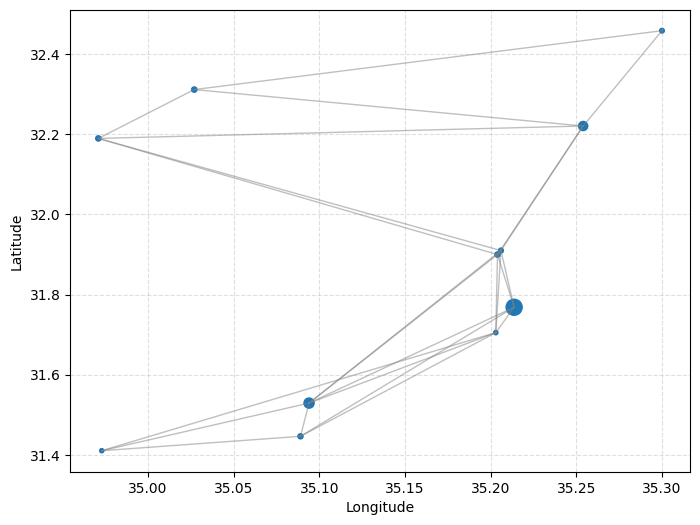

In [15]:
nodes, edges, degree = graph(11)
print("Degree:", degree)
plot_graph(nodes, edges)

## Classical algorithm

In [6]:
def objective_function(Xs, W, S=3, mu=1.0):
    y = np.sum(np.dot(Xs, W))
    constraint = mu*(np.sum(Xs)-S)**2
    return y-constraint

## Quantum algorithm

In [8]:
import numpy as np
from qiskit.primitives import StatevectorSampler
from qiskit.visualization import plot_histogram
from qiskit_optimization import QuadraticProgram
from qiskit_optimization.algorithms import (
    MinimumEigenOptimizer,
    OptimizationResultStatus,
    RecursiveMinimumEigenOptimizer,
    SolutionSample,
)
from qiskit_optimization.minimum_eigensolvers import QAOA, NumPyMinimumEigensolver
from qiskit_optimization.optimizers import COBYLA
from qiskit_optimization.utils import algorithm_globals

In [167]:
nodes, edges, degree = graph(11)

In [168]:
n = len(nodes) # number of nodes
W = np.sum(edges, axis=1)
mu = 1.7 * degree
S = n // 2
print(f"n: {n}, degree: {degree}, mu: {mu}, S: {S}")

# create a QUBO
qubo = QuadraticProgram()

# define the variables
for i in range(n):
    qubo.binary_var(name=f"x{i}")

# term of the cost function
linear = {f"x{i}": -W[i] for i in range(n)}

quadratic = {}
for i in range(n):
    for j in range(n):
        quadratic[(f"x{i}", f"x{j}")] = mu

for i in range(n):
    linear[f"x{i}"] -= mu * 2 * S

constant = mu * S**2

qubo.minimize(linear=linear, quadratic=quadratic, constant = constant)
print(qubo.prettyprint())

n: 11, degree: 7.0, mu: 11.9, S: 5
Problem name: 

Minimize
  11.9*x0^2 + 23.8*x0*x1 + 23.8*x0*x10 + 23.8*x0*x2 + 23.8*x0*x3 + 23.8*x0*x4
  + 23.8*x0*x5 + 23.8*x0*x6 + 23.8*x0*x7 + 23.8*x0*x8 + 23.8*x0*x9 + 11.9*x1^2
  + 23.8*x1*x10 + 23.8*x1*x2 + 23.8*x1*x3 + 23.8*x1*x4 + 23.8*x1*x5 + 23.8*x1*x6
  + 23.8*x1*x7 + 23.8*x1*x8 + 23.8*x1*x9 + 11.9*x10^2 + 23.8*x2*x10 + 11.9*x2^2
  + 23.8*x2*x3 + 23.8*x2*x4 + 23.8*x2*x5 + 23.8*x2*x6 + 23.8*x2*x7 + 23.8*x2*x8
  + 23.8*x2*x9 + 23.8*x3*x10 + 11.9*x3^2 + 23.8*x3*x4 + 23.8*x3*x5 + 23.8*x3*x6
  + 23.8*x3*x7 + 23.8*x3*x8 + 23.8*x3*x9 + 23.8*x4*x10 + 11.9*x4^2 + 23.8*x4*x5
  + 23.8*x4*x6 + 23.8*x4*x7 + 23.8*x4*x8 + 23.8*x4*x9 + 23.8*x5*x10 + 11.9*x5^2
  + 23.8*x5*x6 + 23.8*x5*x7 + 23.8*x5*x8 + 23.8*x5*x9 + 23.8*x6*x10 + 11.9*x6^2
  + 23.8*x6*x7 + 23.8*x6*x8 + 23.8*x6*x9 + 23.8*x7*x10 + 11.9*x7^2 + 23.8*x7*x8
  + 23.8*x7*x9 + 23.8*x8*x10 + 11.9*x8^2 + 23.8*x8*x9 + 23.8*x9*x10 + 11.9*x9^2
  - 125*x0 - 126*x1 - 123*x10 - 125*x2 - 123*x3 - 126*x4 - 124

In [169]:
op, offset = qubo.to_ising()
print("offset: {}".format(offset))
print("operator:")
print(op)

offset: 5.199999999999699
operator:
SparsePauliOp(['IIIIIIIIIIZ', 'IIIIIIIIIZI', 'IIIIIIIIZII', 'IIIIIIIZIII', 'IIIIIIZIIII', 'IIIIIZIIIII', 'IIIIZIIIIII', 'IIIZIIIIIII', 'IIZIIIIIIII', 'IZIIIIIIIII', 'ZIIIIIIIIII', 'IIIIIIIIIZZ', 'IIIIIIIIZIZ', 'IIIIIIIZIIZ', 'IIIIIIZIIIZ', 'IIIIIZIIIIZ', 'IIIIZIIIIIZ', 'IIIZIIIIIIZ', 'IIZIIIIIIIZ', 'IZIIIIIIIIZ', 'ZIIIIIIIIIZ', 'IIIIIIIIZZI', 'IIIIIIIZIZI', 'IIIIIIZIIZI', 'IIIIIZIIIZI', 'IIIIZIIIIZI', 'IIIZIIIIIZI', 'IIZIIIIIIZI', 'IZIIIIIIIZI', 'ZIIIIIIIIZI', 'IIIIIIIZZII', 'IIIIIIZIZII', 'IIIIIZIIZII', 'IIIIZIIIZII', 'IIIZIIIIZII', 'IIZIIIIIZII', 'IZIIIIIIZII', 'ZIIIIIIIZII', 'IIIIIIZZIII', 'IIIIIZIZIII', 'IIIIZIIZIII', 'IIIZIIIZIII', 'IIZIIIIZIII', 'IZIIIIIZIII', 'ZIIIIIIZIII', 'IIIIIZZIIII', 'IIIIZIZIIII', 'IIIZIIZIIII', 'IIZIIIZIIII', 'IZIIIIZIIII', 'ZIIIIIZIIII', 'IIIIZZIIIII', 'IIIZIZIIIII', 'IIZIIZIIIII', 'IZIIIZIIIII', 'ZIIIIZIIIII', 'IIIZZIIIIII', 'IIZIZIIIIII', 'IZIIZIIIIII', 'ZIIIZIIIIII', 'IIZZIIIIIII', 'IZIZIIIIIII', 'ZIIZIIIIIII', 'IZZ

In [170]:
algorithm_globals.random_seed = 10598
qaoa_mes = QAOA(sampler=StatevectorSampler(seed=123), optimizer=COBYLA(), initial_point=[1, 1])
exact_mes = NumPyMinimumEigensolver()

In [171]:
qaoa = MinimumEigenOptimizer(qaoa_mes)  # using QAOA
exact = MinimumEigenOptimizer(exact_mes)  # using the exact classical numpy minimum eigen solver

In [172]:
exact_result = exact.solve(qubo)
print(exact_result.prettyprint())

objective function value: -34.0
variable values: x0=1.0, x1=1.0, x2=0.0, x3=0.0, x4=1.0, x5=0.0, x6=0.0, x7=1.0, x8=0.0, x9=1.0, x10=0.0
status: SUCCESS


In [173]:
qaoa_result = qaoa.solve(qubo)
print(qaoa_result.prettyprint())

objective function value: -34.0
variable values: x0=1.0, x1=1.0, x2=0.0, x3=0.0, x4=1.0, x5=0.0, x6=0.0, x7=1.0, x8=0.0, x9=1.0, x10=0.0
status: SUCCESS


## Result

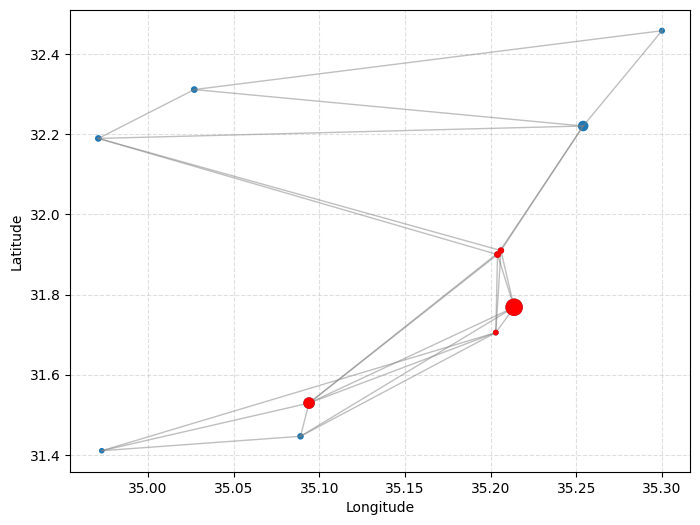

In [174]:
selected_nodes = [i for i in range(n) if qaoa_result.x[i] == 1.0]

plt.figure(figsize=(8, 6))

for i in range(len(edges)):
    for j in range(i + 1, len(edges[i])):
        if edges[i][j] > 0:
            x1, y1 = nodes.iloc[i][["longitude", "latitude"]]
            x2, y2 = nodes.iloc[j][["longitude", "latitude"]]
            plt.plot([x1, x2], [y1, y2], color="gray", alpha=0.5, linewidth=1)

plt.scatter(
    nodes["longitude"],
    nodes["latitude"],
    s=nodes["population_est"] / 3000,
    color="tab:blue"
)

selected_lons = nodes.iloc[selected_nodes]["longitude"]
selected_lats = nodes.iloc[selected_nodes]["latitude"]
selected_pops = nodes.iloc[selected_nodes]["population_est"]

plt.scatter(
    selected_lons,
    selected_lats,
    s=selected_pops / 3000,
    color="red",
    zorder=5
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True, linestyle="--", alpha=0.4)
plt.show()